# Field-level inference of the initial conditions from two $\kappa$ maps

We sample the joint posterior of $(\Omega_c,\sigma_8)$ and the $\mathrm{MESH}^3$ white-noise initial-condition (IC) field behind two convergence maps with Microcanonical Langevin Monte Carlo (MCLMC), on one A100. The forward model is that of notebook 14, Part II (Euclid): 2LPT on the lightcone, 22 capped equal-volume shells from `R_MIN`, Born convergence for DES Y3 source bins 2 and 3 at the Euclid IST:F source density, and a Gaussian pixel likelihood on $\kappa$ band-limited to $2\le\ell\le$ `ELL_MAX`.

This notebook presents the field part of the posterior. The chain behind it ran on one A100 at `MESH = 128`: 300 tuning steps, then 10 batches of 10 draws, one every 5 MCLMC steps. Its output is read from `mcmc_results/` next to this notebook, and `RUN_SAMPLING = True` reruns it on a GPU. The chain moves the cosmology slowly (an effective sample size of 3 to 5 in 100 draws), so notebook 17 treats the cosmology separately, at fixed IC.

From the 100 draws we show:
1. the IC: truth, posterior mean, posterior standard deviation and residual, in 3D and projected along each line of sight with the lensing kernel;
2. the transfer function and coherence of the IC against the truth;
3. the posterior $\kappa$ of each source bin: truth, mean, standard deviation and residual;
4. the coherence and transfer function of the posterior $\kappa$ against the truth;
5. the starlet $\ell_1$ norm of the posterior $\kappa$ against that of the truth.

At 128³ one gradient takes 8 s on an A100. A run costs (`NUM_WARMUP` + `NUM_SAMPLES` × `BATCH_COUNT` × `THINNING`) MCLMC steps of two gradients each, about 4 h.

## 1. Environment

Everything runs in float64. The spherical-harmonic transforms use the CUDA backend (`jax_cuda`) on a GPU and the JAX one on a CPU, where this notebook only reads the run and plots it.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["HF_DATASETS_OFFLINE"] = "1"

import json
import shutil
import threading
from pathlib import Path

import datasets
import healpy as hp
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax._src import dispatch
from numpyro.handlers import condition, reparam, seed, trace
from numpyro.infer.reparam import Reparam
from numpyro.infer.util import potential_energy
from scipy.special import ndtri

import jax_fli as jfli
from jax_fli.data.nz import get_des_y3_nz_shear, plot_nz
from jax_fli.fields.density import plot_3d_density
from jax_fli.summary_statistics import starlet_coefficients_spherical

datasets.disable_progress_bar()
jax.config.update("jax_enable_x64", True)
MAP2ALM = "jax_cuda" if jax.default_backend() == "gpu" else "jax"
print(jax.devices(), MAP2ALM)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[CpuDevice(id=0)] jax


## 2. Parameters

MCLMC tunes its step size and its momentum decoherence length over `NUM_WARMUP` steps, then stores `NUM_SAMPLES` draws per batch for `BATCH_COUNT` batches, one every `THINNING` steps. An MCLMC step is a single integration step of two gradients, so successive draws are correlated and need thinning. The `MCLMC_*` values set the energy-error target, the initial step size of the tuning and the diagonal preconditioning. The chain starts at the truth (`INIT = "truth"`), so the tuning only has to adapt the sampler. `ROOT` holds the run, in `mcmc_results/` next to this notebook.

In [2]:
RUN_SAMPLING = False  # True reruns the chain on a GPU (about 4 h on an A100); False reads it from ROOT
MESH = 128
INIT = "truth"
NUM_WARMUP = 300  # MCLMC tuning steps
NUM_SAMPLES = 10  # draws per batch
BATCH_COUNT = 10
THINNING = 5  # MCLMC steps per stored draw
MCLMC_ENERGY_VAR = 1e-3  # target energy error per dimension
MCLMC_INIT_STEP = 0.02  # initial tuning step, in units of sqrt(dimension)
MCLMC_DIAG_PRECOND = False  # diagonal preconditioning estimated during tuning
ROOT = "mcmc_results"  # the runs, next to this notebook

## 3. Survey and resolution

The two source bins are DES Y3 bins 2 and 3 with the Euclid IST:F source density (30 galaxies/arcmin² over four bins) and shape noise $\sigma_e=0.30/\sqrt2$ per component. The mesh resolves wavenumbers up to $k_{\rm Nyq}=\pi\,\mathrm{MESH}/L$. At the peak $\chi_{\rm peak}$ of the lensing efficiency of the lower bin this is the multipole $\ell_{\rm Nyq}=k_{\rm Nyq}\chi_{\rm peak}$, and the likelihood keeps $2\le\ell\le$ `ELL_MAX` $=\lfloor\ell_{\rm Nyq}\rfloor$. The maps live at `NSIDE`, twice the smallest HEALPix resolution with $2N_{\rm side}\ge$ `ELL_MAX`.

MESH 128^3, box 4595 Mpc/h, ELL_MAX 57, PAINT_NSIDE 32, NSIDE 64, output mcmc_results/FIELDLEVEL_MESH128_truth


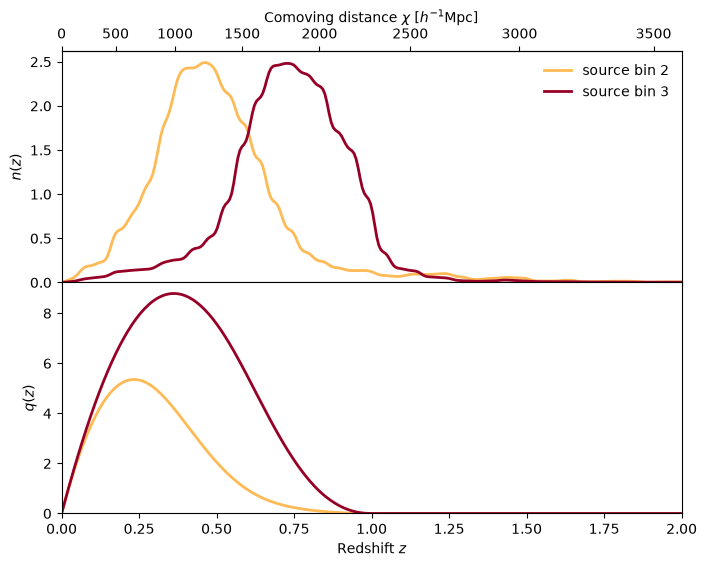

In [3]:
MAX_Z = 1.0
N_SHELLS, MIN_WIDTH, MAX_WIDTH, R_MIN = 22, 50.0, 150.0, 300.0  # Mpc/h
SEED = 0
cosmo = jc.Planck18()
box = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, MAX_Z, (0.5, 0.5, 0.5)))
NZ = [get_des_y3_nz_shear(gals_per_arcmin2=[30.0 / 4] * 4, zmax=MAX_Z)[i] for i in (1, 2)]
SIGMA_E = 0.30 / np.sqrt(2)
N_BINS = len(NZ)
BIN = ["source bin 2", "source bin 3"]

# lensing efficiency of each bin on a grid of comoving distance
chi = np.linspace(1.0, box[0] / 2, 2000)
z_src = np.linspace(1e-3, MAX_Z, 1000)
chi_src = np.asarray(jc.background.radial_comoving_distance(cosmo, jc.utils.z2a(jnp.asarray(z_src))))
a_chi = np.asarray(jc.background.a_of_chi(cosmo, jnp.asarray(chi)))
efficiency = []
for nz in NZ:
    n_z = np.asarray(nz(jnp.asarray(z_src)))
    geometry = np.clip(1 - chi[:, None] / chi_src, 0, None)
    efficiency.append(chi / a_chi * np.trapezoid(n_z * geometry, z_src, axis=1) / np.trapezoid(n_z, z_src))
chi_peak = min(chi[np.argmax(q)] for q in efficiency)

ELL_MAX = int(np.pi * MESH / box[0] * chi_peak)
ELL_TAPER = round(0.125 * ELL_MAX)
PAINT_NSIDE = int(2 ** np.ceil(np.log2(ELL_MAX / 2)))
NSIDE = 2 * PAINT_NSIDE
OUT = Path(ROOT) / f"FIELDLEVEL_MESH{MESH}_{INIT}"
CHAIN = OUT / "chain"
TRUTH = OUT / "truth"
OUT.mkdir(parents=True, exist_ok=True)
print(
    f"MESH {MESH}^3, box {box[0]:.0f} Mpc/h, ELL_MAX {ELL_MAX}, PAINT_NSIDE {PAINT_NSIDE}, NSIDE {NSIDE}, output {OUT}"
)
plot_nz(NZ, cosmo=cosmo, labels=BIN)
plt.show()

## 4. Model

`full_field_probmodel` in LPT mode (2LPT), with capped equal-volume shells from `r_min`, the per-shell resolution cut and $\ell\ge2$, as in notebook 14. With `log_observable=True` the model records, for every draw, the noiseless band-limited $\kappa$ it predicts for the data (`predicted_observable_i`). `sample2catalog` saves it next to the IC, so the posterior $\kappa$ below needs no further forward-model evaluation.

In [4]:
priors = {"Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5), "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0)}
config = jfli.ppl.Configurations(
    mesh_size=(MESH,) * 3,
    box_size=box,
    halo_size=(0, 0),
    field_sharding=None,
    sim_mode="lpt",
    lpt_order=2,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    number_of_shells=N_SHELLS,
    shell_spacing="equal_vol",
    min_width=MIN_WIDTH,
    max_width=MAX_WIDTH,
    r_min=R_MIN,
    resolution_cut=True,
    geometry="spherical",
    scheme="bilinear",
    nside=NSIDE,
    paint_nside=PAINT_NSIDE,
    kernel_width_pixels=0.8,
    observer_position=(0.5, 0.5, 0.5),
    lensing_output="convergence",
    normalization="global",
    map2alm_method=MAP2ALM,
    min_redshift=0.001,
    max_redshift=MAX_Z,
    n_integrate=8,
    fiducial_cosmology=jc.Planck18,
    nz_shear=NZ,
    priors=priors,
    sigma_e=SIGMA_E,
    ell_max=ELL_MAX,
    ell_taper_width=ELL_TAPER,
    ell_min=2,
    log_observable=True,
)
model = jfli.ppl.full_field_probmodel(config)

## 5. Mock data

The truth is Planck18 and a white-noise field drawn at `SEED`. Conditioning the model on them and tracing it gives the data (the `observable_i` sites, with the shape noise the likelihood draws) and the noiseless truth $\kappa$ (`predicted_observable_i`). The sampling run saves the truth IC, the truth $\kappa$ and the data to `truth/` as parquet catalogues, and every figure below reads them from there.

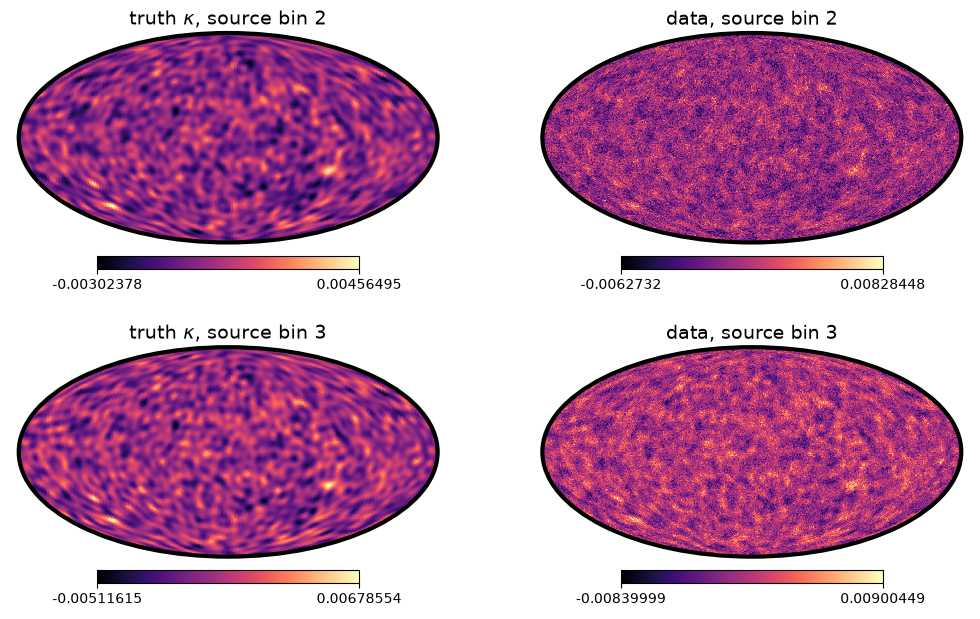

In [5]:
fiducial_base = {
    f"{name}_base": float(
        ndtri((float(getattr(cosmo, name)) - float(prior.low)) / (float(prior.high) - float(prior.low)))
    )
    for name, prior in priors.items()
}
white_truth = jax.random.normal(jax.random.PRNGKey(SEED), config.mesh_size)
truth = {k: jnp.asarray(v) for k, v in fiducial_base.items()} | {"initial_conditions": white_truth}
if RUN_SAMPLING:
    mock = trace(seed(condition(model, data=truth), SEED)).get_trace()
    data = {f"observable_{b}": mock[f"observable_{b}"]["value"] for b in range(N_BINS)}
    kappa_meta = mock["observable_meta_data"]["value"]
    kappa_truth = jfli.SphericalKappaField.FromDensityMetadata(
        array=jnp.stack([mock[f"predicted_observable_{b}"]["value"] for b in range(N_BINS)]), field=kappa_meta
    )
    kappa_data = jfli.SphericalKappaField.FromDensityMetadata(array=jnp.stack(list(data.values())), field=kappa_meta)
    # the IC carries no shell metadata: set it as sample2catalog does for the IC draws
    ic_truth = jfli.interpolate_initial_conditions(
        white_truth,
        config.mesh_size,
        config.box_size,
        cosmo=cosmo,
        observer_position=config.observer_position,
        halo_size=config.halo_size,
        nside=config.nside,
    ).replace(
        z_sources=jnp.zeros(1), comoving_centers=jnp.zeros(1), scale_factors=jnp.zeros(1), density_width=jnp.zeros(1)
    )
    TRUTH.mkdir(exist_ok=True)
    for name, field in (("ic_truth", ic_truth), ("kappa_truth", kappa_truth), ("kappa_data", kappa_data)):
        jfli.io.Catalog(field=[field], cosmology=[cosmo]).to_parquet(str(TRUTH / f"{name}.parquet"))

ic_truth = jfli.io.Catalog.from_parquet(str(TRUTH / "ic_truth.parquet")).field[0]
kappa_truth = jfli.io.Catalog.from_parquet(str(TRUTH / "kappa_truth.parquet")).field[0]
kappa_data = jfli.io.Catalog.from_parquet(str(TRUTH / "kappa_data.parquet")).field[0]
truth_catalog = jfli.io.Catalog(field=[ic_truth], cosmology=[cosmo])

fig, axes = plt.subplots(N_BINS, 2, figsize=(10, 3.2 * N_BINS), squeeze=False)
kappa_truth.plot(ax=list(axes[:, 0]), titles=[f"truth $\\kappa$, {b}" for b in BIN])
kappa_data.plot(ax=list(axes[:, 1]), titles=[f"data, {b}" for b in BIN])
plt.show()

## 6. Posterior and cosmology preconditioning

The posterior is the model conditioned on the data. Its two cosmological base variables are much narrower than the white field, whose prior width is 1. We therefore sample $z_k=\theta_k/s_k$, with $s_k$ the conditional posterior width of each base variable $\theta_k$ at the truth, measured by a central difference of the gradient. A NumPyro `reparam` handler does this change of variables, and leaves the prior and the model unchanged. This section and the next run only with `RUN_SAMPLING = True`.

In [6]:
class ScaleReparam(Reparam):
    # theta = scale * z: the sampler moves z, whose posterior width is ~1 when scale is the width of theta
    def __init__(self, scale):
        self.scale = scale

    def __call__(self, name, fn, obs):
        z = numpyro.sample(
            f"{name}_z", dist.TransformedDistribution(fn, dist.transforms.AffineTransform(0.0, 1.0 / self.scale))
        )
        return None, self.scale * z


if RUN_SAMPLING:
    posterior = condition(model, data=data)

    def potential(position):
        return potential_energy(posterior, (), {}, position)

    value_and_grad = jax.jit(jax.value_and_grad(potential))
    scales = {}
    for name in fiducial_base:
        grad_plus = value_and_grad(truth | {name: truth[name] + 1e-3})[1][name]
        grad_minus = value_and_grad(truth | {name: truth[name] - 1e-3})[1][name]
        scales[name] = float((2e-3 / (grad_plus - grad_minus)) ** 0.5)
    print("conditional widths of the base variables:", scales)

    sampled_posterior = reparam(posterior, config={name: ScaleReparam(s) for name, s in scales.items()})
    if INIT == "truth":
        start = {f"{name}_z": truth[name] / s for name, s in scales.items()} | {"initial_conditions": white_truth}
    else:
        start = {f"{name}_z": jnp.asarray(0.0) for name in scales} | {
            "initial_conditions": 0.3 * jax.random.normal(jax.random.PRNGKey(30), config.mesh_size)
        }

## 7. Sampling

`jfli.infer.batched_sampling` tunes MCLMC (step size and momentum decoherence length), then samples in batches and saves the sampler state after each batch, so re-running this cell resumes an interrupted chain. The tuning runs in chunks of `warmup_chunk` steps and is saved after each one: `chain/warmup.log` records its progress, and an interrupted tuning resumes where it stopped. For each draw, `jfli.infer.colour_ic` turns the white field into the physical IC with the draw's cosmology, and `jfli.infer.sample2catalog` writes to `chain/samples/`:
- `samples/samples_<batch>.parquet`: the physical IC and the cosmology;
- `observable_fields/fields_<batch>.parquet`: the band-limited $\kappa$ of both bins.

jax-cosmo caches its background tables on the host and computes them with an eager `lax.scan` at every new cosmology. JAX keeps every one of these compiled scans, and the kernel reaches its limit of 65530 memory mappings after about 3 h of sampling. A background thread therefore clears that compilation cache every 5 minutes. For MCLMC the `Mean Accept` column of `metrics.md` is the fraction of steps free of NaN.

In [7]:
if RUN_SAMPLING:
    stop = threading.Event()

    def clear_eager_cache():
        # the eager jit(scan) of jax-cosmo's host cache, one per cosmology: free them before the mapping limit
        while not stop.wait(300):
            dispatch.xla_primitive_callable.cache_clear()

    threading.Thread(target=clear_eager_cache, daemon=True).start()
    jfli.infer.batched_sampling(
        sampled_posterior,
        path=str(CHAIN),
        rng_key=jax.random.PRNGKey(1),
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        batch_count=BATCH_COUNT,
        sampler="MCLMC",
        thinning=THINNING,
        mclmc_desired_energy_var=MCLMC_ENERGY_VAR,
        mclmc_init_step_size=MCLMC_INIT_STEP * np.sqrt(MESH**3 + 2),
        mclmc_diagonal_preconditioning=MCLMC_DIAG_PRECOND,
        init_params=start,
        progress_bar=True,
        print_rate=1,
        save_callback=jfli.infer.sample2catalog(config),
        post_process=jfli.infer.colour_ic(config),
    )
    stop.set()
print((CHAIN / "metrics.md").read_text())
print("tuned MCLMC parameters:", {k: float(v) for k, v in np.load(CHAIN / "warmup_params.npz").items()})

| Batch | Avg Steps | Divergences | Mean Accept |
|-------|-----------|-------------|-------------|
| 0 | N/A | N/A | 1.000 |
| 1 | N/A | N/A | 1.000 |
| 2 | N/A | N/A | 1.000 |
| 3 | N/A | N/A | 1.000 |
| 4 | N/A | N/A | 1.000 |
| 5 | N/A | N/A | 1.000 |
| 6 | N/A | N/A | 1.000 |
| 7 | N/A | N/A | 1.000 |
| 8 | N/A | N/A | 1.000 |
| 9 | N/A | N/A | 1.000 |

tuned MCLMC parameters: {'L': 505.6555549132908, 'step_size': 77.14415255083469}


## 8. Posterior of the initial conditions

`jfli.io.extract_catalog` streams the draws and accumulates the mean and standard deviation of the IC, and the IC transfer function and coherence against the truth.

In [8]:
def batch_index(path):
    # samples_<batch>.parquet / fields_<batch>.parquet -> batch
    return int(path.stem.split("_")[1])


ic_files = sorted((CHAIN / "samples" / "samples").glob("samples_*.parquet"), key=batch_index)
kappa_files = sorted((CHAIN / "samples" / "observable_fields").glob("fields_*.parquet"), key=batch_index)
posterior_ic = jfli.io.extract_catalog(
    set_name=f"MCLMC {MESH}^3",
    cosmo_keys=["Omega_c"],
    patterns=[str(CHAIN / "samples")],
    truth=truth_catalog,
    field_statistic=True,
    power_statistic=True,
)
ic_mean, ic_std = posterior_ic.mean_field[0], posterior_ic.std_field[0]
print(f"{len(ic_files)} batches, {np.asarray(posterior_ic.cosmo['Omega_c']).size} draws")

10 batches, 100 draws


## 9. The initial conditions in 3D

The three visible faces of the box: truth, posterior mean, posterior standard deviation and residual. The observer is at the centre. The two $\kappa$ maps constrain the IC only through its projection along each line of sight, so the posterior mean is a faint image of the truth.

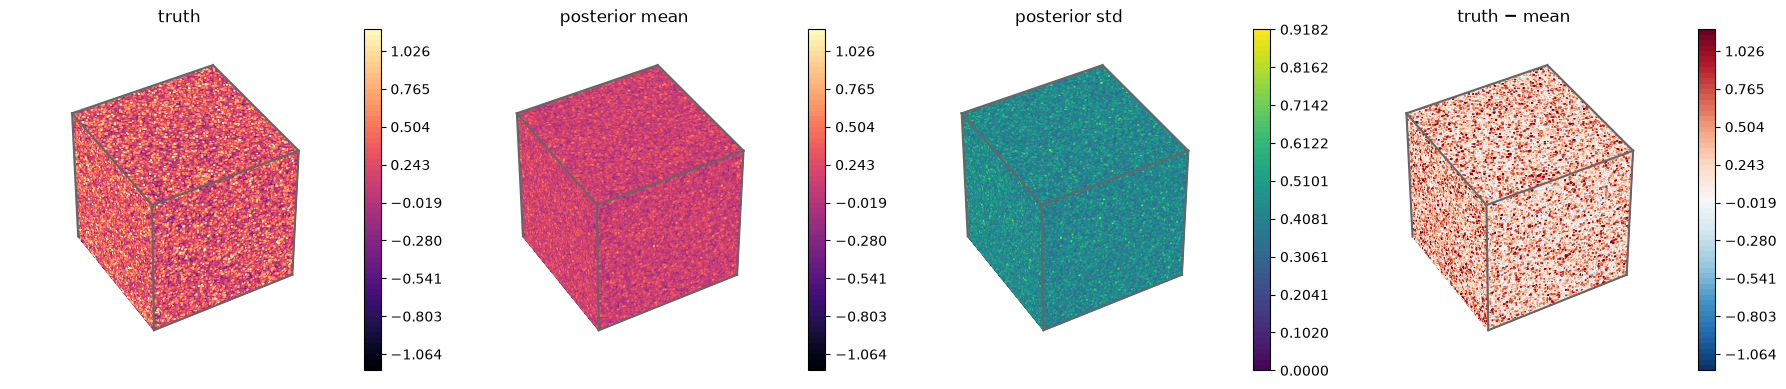

In [9]:
lim = float(jnp.percentile(jnp.abs(ic_truth.array), 99.5))
panels = [
    (ic_truth, "truth", "magma", -lim, lim),
    (ic_mean, "posterior mean", "magma", -lim, lim),
    (ic_std, "posterior std", "viridis", 0.0, max(float(ic_std.array.max()), 1e-12)),
    (ic_truth - ic_mean, "truth $-$ mean", "RdBu_r", -lim, lim),
]
fig = plt.figure(figsize=(22, 5.6))
for i, (field, title, cmap, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_3d_density(ax, field.array, project_slices=1, vmin=vmin, vmax=vmax, cmap=cmap, labels=("", "", ""))
    ax.set_title(title)
plt.show()

## 10. Transfer function and coherence of the initial conditions

For each draw $p$ and the truth $t$, the 3D power spectra give the transfer function $T(k)=\sqrt{P^{pp}(k)/P^{tt}(k)}$ and the coherence $r(k)=P^{tp}(k)/\sqrt{P^{tt}(k)P^{pp}(k)}$. The line is the mean over the draws and the band their standard deviation. The coherence measures how much of each 3D mode the two $\kappa$ maps pin down, and the transfer function measures the power of the draws.

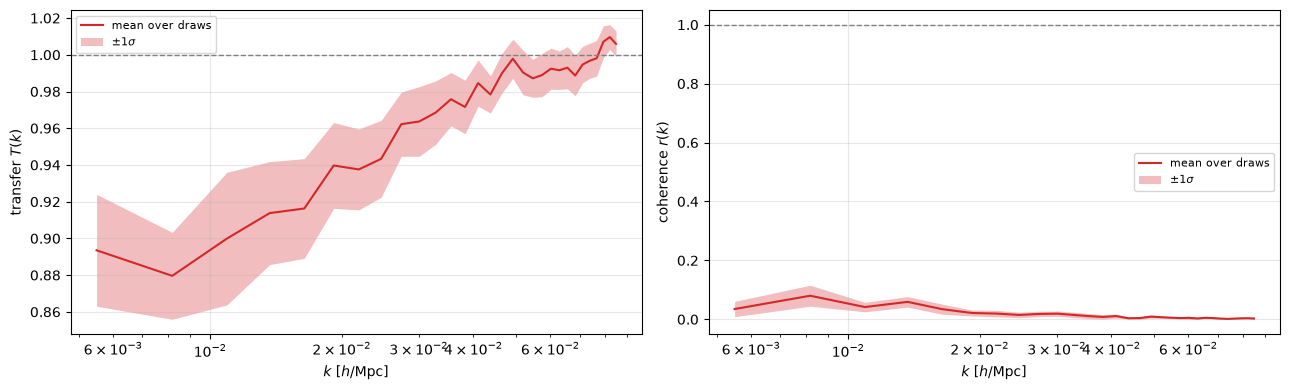

In [10]:
mean_tf, std_tf, mean_coh, std_coh = posterior_ic.power_spectra
k = np.asarray(mean_tf.wavenumber)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mean, std, ylabel in (
    (axes[0], mean_tf, std_tf, "transfer $T(k)$"),
    (axes[1], mean_coh, std_coh, "coherence $r(k)$"),
):
    mean, std = np.asarray(mean.array).reshape(-1, k.size)[0], np.asarray(std.array).reshape(-1, k.size)[0]
    ax.plot(k, mean, color="C3", label="mean over draws")
    ax.fill_between(k, mean - std, mean + std, color="C3", alpha=0.3, lw=0, label="$\\pm1\\sigma$")
    ax.axhline(1.0, color="0.5", ls="--", lw=1)
    ax.set(xscale="log", xlabel="$k$ [$h$/Mpc]", ylabel=ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. The projected initial conditions

`DensityField.sky_projection` projects a 3D field along each line of sight with the lensing efficiency of each source bin, from `R_MIN` to the edge of the lightcone: the part of the IC that the two $\kappa$ maps constrain. The sampling run projects every draw and saves the projections to `projected_ic/`, and `extract_catalog` accumulates their mean and standard deviation.

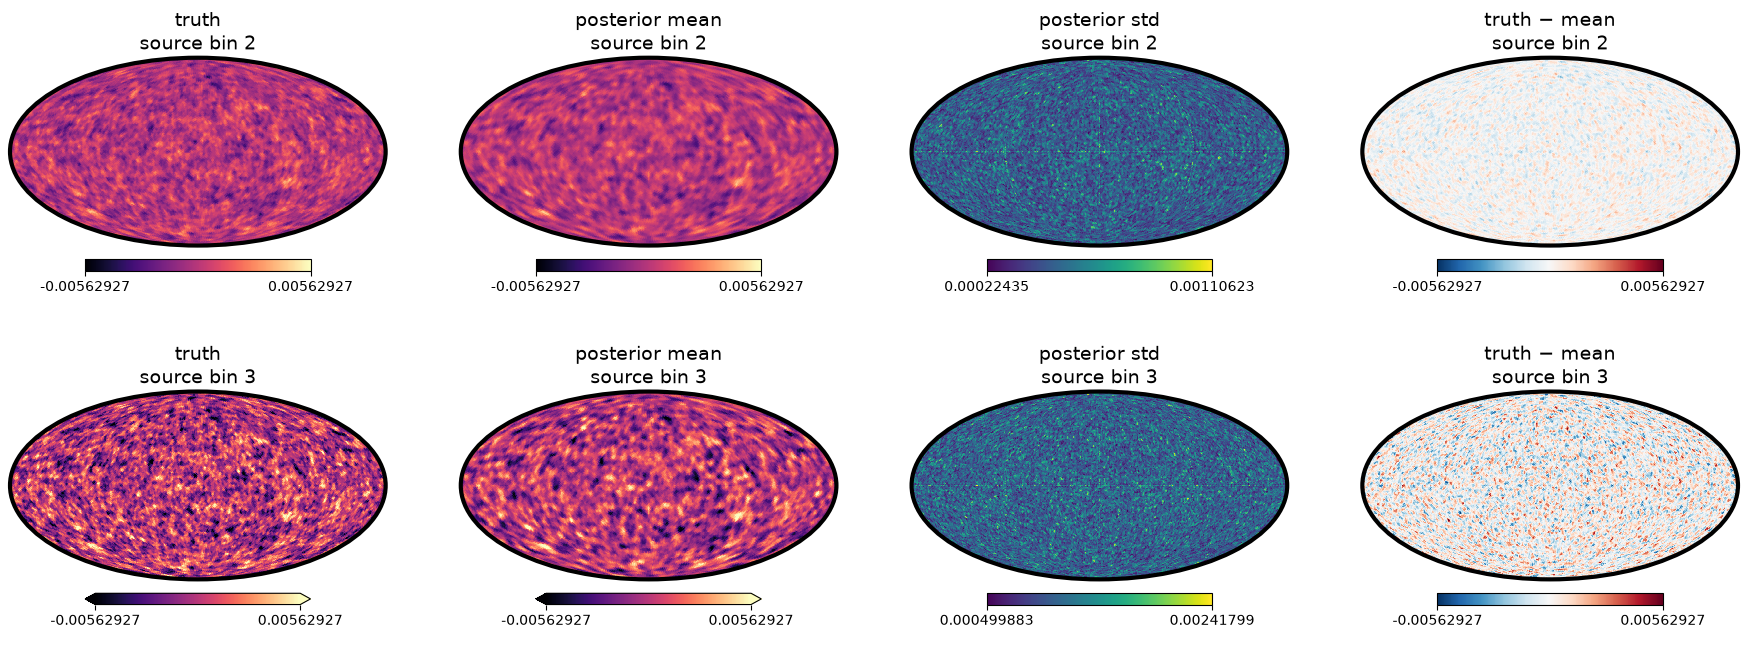

In [11]:
projection_dir = OUT / "projected_ic"
projection_truth = ic_truth.sky_projection(cosmo, NZ, nside=NSIDE, r_min=R_MIN)
if RUN_SAMPLING:
    shutil.rmtree(projection_dir, ignore_errors=True)
    projection_dir.mkdir()
    for f in ic_files:
        draws = jfli.io.Catalog.from_parquet(str(f))
        projections = [ic.sky_projection(cosmo, NZ, nside=NSIDE, r_min=R_MIN) for ic in draws.field]
        jfli.io.Catalog(field=projections, cosmology=draws.cosmology).to_parquet(str(projection_dir / f.name))
projected = jfli.io.extract_catalog(
    set_name="projected IC", cosmo_keys=["Omega_c"], patterns=[str(projection_dir / "*.parquet")], field_statistic=True
)
projection_mean, projection_std = projected.mean_field[0], projected.std_field[0]

lim = float(jnp.percentile(jnp.abs(projection_truth.array), 99.8))
fig, axes = plt.subplots(N_BINS, 4, figsize=(18, 3.4 * N_BINS), squeeze=False)
projection_truth.plot(ax=list(axes[:, 0]), titles=[f"truth\n{b}" for b in BIN], vmin=-lim, vmax=lim)
projection_mean.plot(ax=list(axes[:, 1]), titles=[f"posterior mean\n{b}" for b in BIN], vmin=-lim, vmax=lim)
projection_std.plot(ax=list(axes[:, 2]), titles=[f"posterior std\n{b}" for b in BIN], cmap="viridis")
(projection_truth - projection_mean).plot(
    ax=list(axes[:, 3]), titles=[f"truth $-$ mean\n{b}" for b in BIN], vmin=-lim, vmax=lim, cmap="RdBu_r"
)
plt.show()

## 12. The posterior $\kappa$

The band-limited $\kappa$ that each draw predicts for the data, saved during sampling: truth, posterior mean, posterior standard deviation and residual.

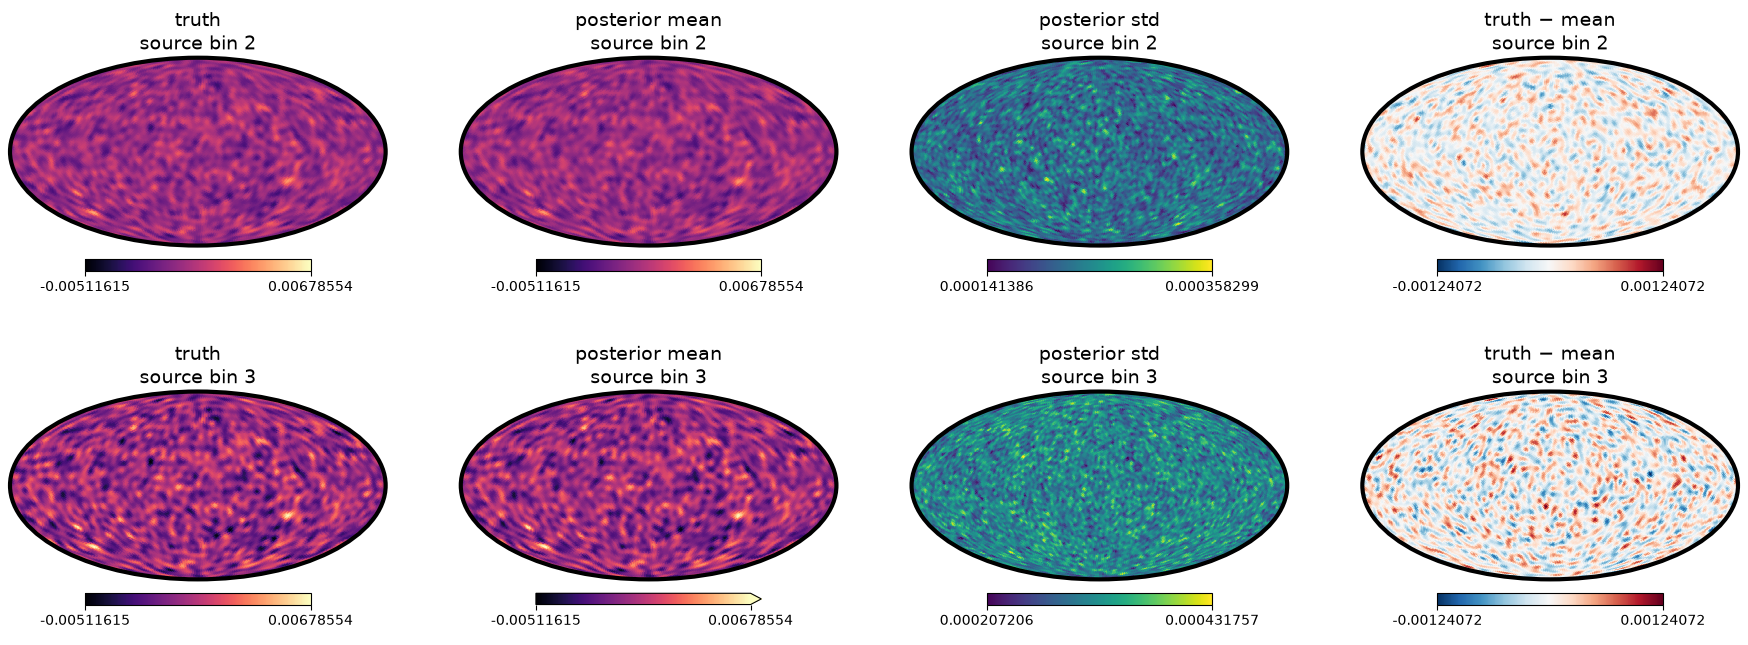

In [12]:
posterior_kappa = jfli.io.extract_catalog(
    set_name="posterior kappa",
    cosmo_keys=["Omega_c"],
    patterns=[str(CHAIN / "samples" / "observable_fields" / "*.parquet")],
    field_statistic=True,
)
kappa_mean, kappa_std = posterior_kappa.mean_field[0], posterior_kappa.std_field[0]

vmin, vmax = float(kappa_truth.array.min()), float(kappa_truth.array.max())
lim = float(jnp.abs((kappa_truth - kappa_mean).array).max())
fig, axes = plt.subplots(N_BINS, 4, figsize=(18, 3.4 * N_BINS), squeeze=False)
kappa_truth.plot(ax=list(axes[:, 0]), titles=[f"truth\n{b}" for b in BIN], vmin=vmin, vmax=vmax)
kappa_mean.plot(ax=list(axes[:, 1]), titles=[f"posterior mean\n{b}" for b in BIN], vmin=vmin, vmax=vmax)
kappa_std.plot(ax=list(axes[:, 2]), titles=[f"posterior std\n{b}" for b in BIN], cmap="viridis")
(kappa_truth - kappa_mean).plot(
    ax=list(axes[:, 3]), titles=[f"truth $-$ mean\n{b}" for b in BIN], vmin=-lim, vmax=lim, cmap="RdBu_r"
)
plt.show()

## 13. Coherence and transfer function of the posterior $\kappa$

For each draw $p$ and the truth $t$: the coherence $r(\ell)=C_\ell^{tp}/\sqrt{C_\ell^{tt}C_\ell^{pp}}$ and the transfer function $T(\ell)=\sqrt{C_\ell^{pp}/C_\ell^{tt}}$, up to `ELL_MAX`. The line is the mean over the draws and the band their standard deviation. A perfect reconstruction sits at 1. The grey band marks the cosine taper of the likelihood, $\ell>$ `ELL_MAX` $-$ `ELL_TAPER`, where the truth has almost no power and the transfer function diverges.

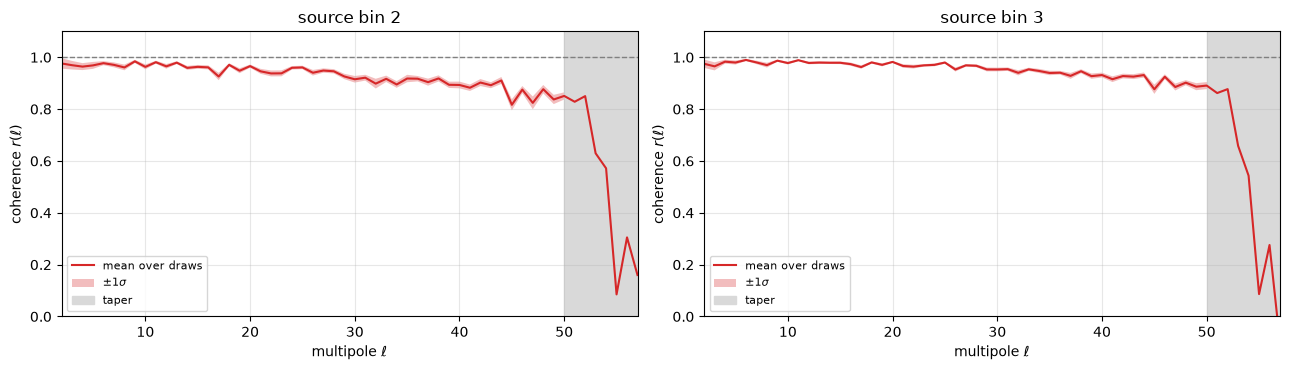

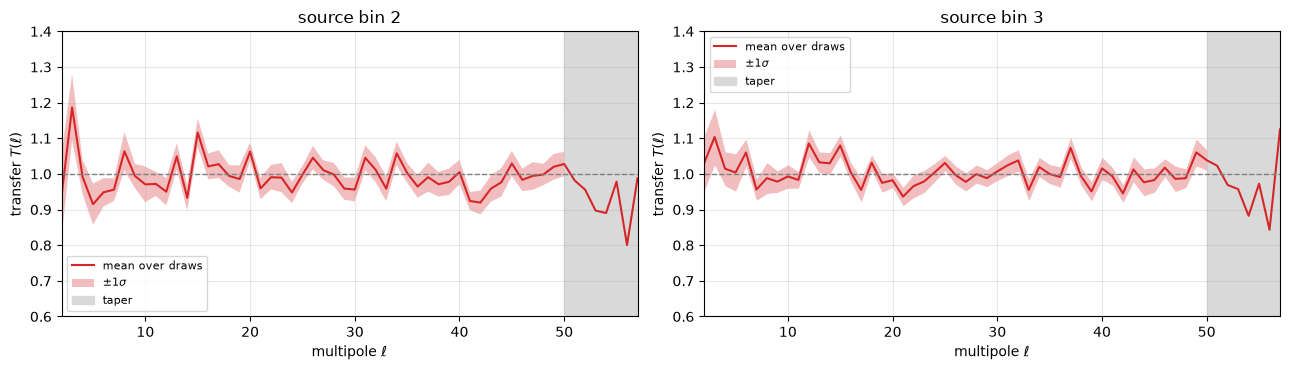

In [13]:
kappa_draws = [kappa for f in kappa_files for kappa in jfli.io.Catalog.from_parquet(str(f)).field]
coherence_draws = [kappa_truth.coherence(k, lmax=ELL_MAX, method="healpy") for k in kappa_draws]
transfer_draws = [kappa_truth.transfer(k, lmax=ELL_MAX, method="healpy") for k in kappa_draws]
ell = np.asarray(coherence_draws[0].wavenumber)
# (draw, bin, ell)
coherence = np.stack([np.asarray(c.array) for c in coherence_draws])
transfer = np.stack([np.asarray(t.array) for t in transfer_draws])
for spectra, ylabel, ylim in (
    (coherence, "coherence $r(\\ell)$", (0.0, 1.1)),
    (transfer, "transfer $T(\\ell)$", (0.6, 1.4)),
):
    fig, axes = plt.subplots(1, N_BINS, figsize=(6.5 * N_BINS, 3.8), squeeze=False)
    for b, ax in enumerate(axes[0]):
        mean, std = spectra[:, b].mean(axis=0), spectra[:, b].std(axis=0)
        ax.plot(ell, mean, color="C3", label="mean over draws")
        ax.fill_between(ell, mean - std, mean + std, color="C3", alpha=0.3, lw=0, label="$\\pm1\\sigma$")
        ax.axvspan(ELL_MAX - ELL_TAPER, ELL_MAX, color="0.85", label="taper")
        ax.axhline(1.0, color="0.5", ls="--", lw=1)
        ax.set(xlabel="multipole $\\ell$", ylabel=ylabel, title=BIN[b], xlim=(2, ELL_MAX), ylim=ylim)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Starlet $\ell_1$ norm of the posterior $\kappa$

The starlet transform (`starlet_coefficients_spherical`) splits a map into five scales. We first bring the band-limited maps to `ST_NSIDE`, the smallest resolution with $3N_{\rm side}\ge$ `ELL_MAX`, so that every scale lies inside the band. At each scale $j$ the coefficients are expressed as $\nu=w_j/\sigma_j$, with $\sigma_j$ the standard deviation of the truth's coefficients, and the $\ell_1$ norm of a $\nu$ bin is the sum of $|\nu|$ over its pixels (Ajani et al. 2021). Black dashed: the truth; line and band: mean and standard deviation over the draws.

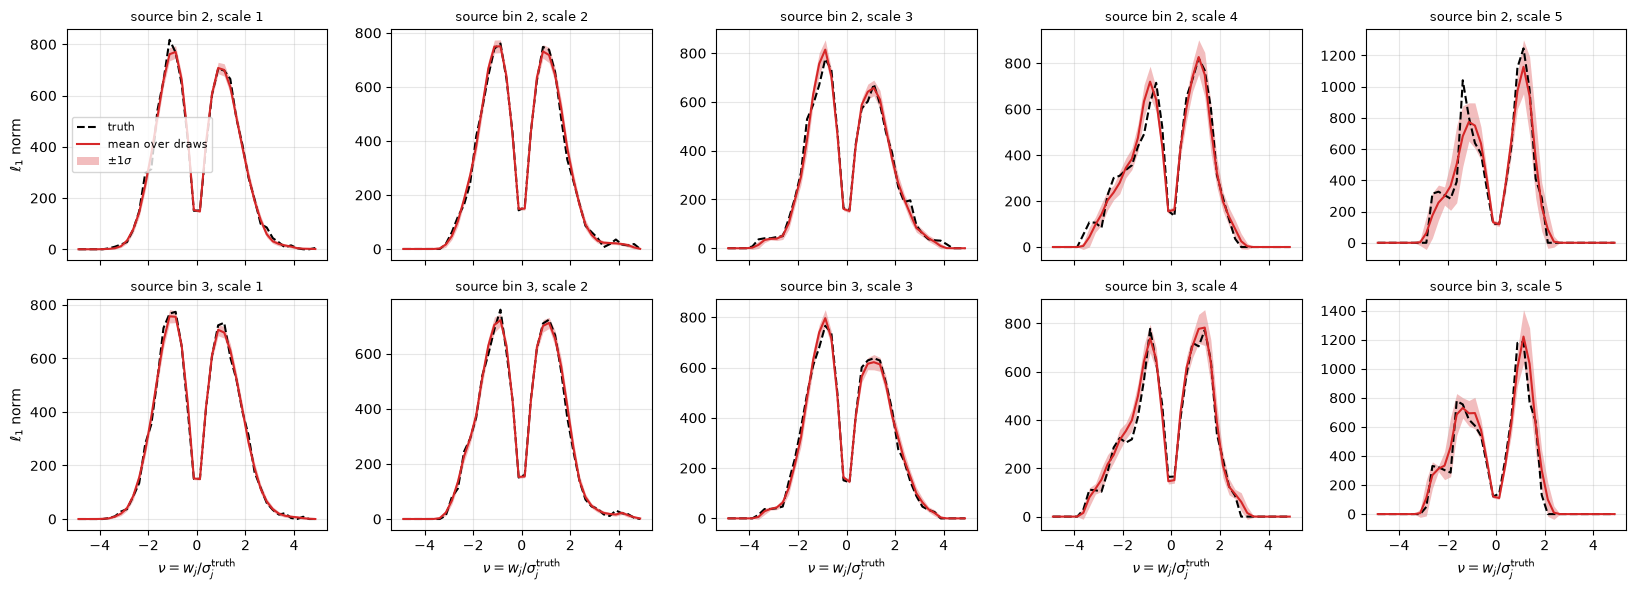

In [14]:
ST_NSIDE, N_SCALES = int(2 ** np.ceil(np.log2(ELL_MAX / 3))), 5
NU_EDGES = np.linspace(-5.0, 5.0, 41)
NU = 0.5 * (NU_EDGES[1:] + NU_EDGES[:-1])


def starlet(kappa_map):
    # starlet coefficients (scale, pixel) of one band-limited map, resampled to ST_NSIDE through its harmonic coefficients
    resampled = hp.alm2map(hp.map2alm(np.asarray(kappa_map, dtype=np.float64), lmax=ELL_MAX), ST_NSIDE, lmax=ELL_MAX)
    return starlet_coefficients_spherical(resampled, nside=ST_NSIDE, nscales=N_SCALES)[0]


def l1_norm(coefficients, sigma):
    # per scale: nu = w_j / sigma_j, then the sum of |nu| over the pixels of each nu bin
    norm = np.zeros((N_SCALES, len(NU)))
    for j in range(N_SCALES):
        nu = coefficients[j] / sigma[j]
        norm[j] = np.histogram(nu, bins=NU_EDGES, weights=np.abs(nu))[0]
    return norm


fig, axes = plt.subplots(N_BINS, N_SCALES, figsize=(3.3 * N_SCALES, 3.0 * N_BINS), sharex=True, squeeze=False)
for b in range(N_BINS):
    truth_coefficients = starlet(kappa_truth.array[b])
    sigma = truth_coefficients.std(axis=1)
    l1_truth = l1_norm(truth_coefficients, sigma)
    l1_draws = np.array([l1_norm(starlet(k.array[b]), sigma) for k in kappa_draws])
    for j, ax in enumerate(axes[b]):
        mean, std = l1_draws[:, j].mean(axis=0), l1_draws[:, j].std(axis=0)
        ax.plot(NU, l1_truth[j], "k--", label="truth")
        ax.plot(NU, mean, color="C3", label="mean over draws")
        ax.fill_between(NU, mean - std, mean + std, color="C3", alpha=0.3, lw=0, label="$\\pm1\\sigma$")
        ax.set_title(f"{BIN[b]}, scale {j + 1}", fontsize=9)
        ax.grid(alpha=0.3)
    axes[b, 0].set_ylabel("$\\ell_1$ norm")
for ax in axes[-1]:
    ax.set_xlabel("$\\nu = w_j/\\sigma_j^{\\rm truth}$")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 15. Summary

The run directory holds everything needed to redo the figures without a GPU: the draws (`chain/samples/samples/`, IC and cosmology), the posterior $\kappa$ (`chain/samples/observable_fields/`), the projected IC (`projected_ic/`) and the truth (`truth/`). The summary gives the mean coherence and transfer function of the posterior $\kappa$ over $2\le\ell<$ `ELL_MAX` $-$ `ELL_TAPER`.

In [15]:
summary = {
    "mesh": MESH,
    "ell_max": ELL_MAX,
    "draws": len(kappa_draws),
    "kappa_coherence": [float(np.nanmean(coherence[:, b, 2 : ELL_MAX - ELL_TAPER])) for b in range(N_BINS)],
    "kappa_transfer": [float(np.nanmean(transfer[:, b, 2 : ELL_MAX - ELL_TAPER])) for b in range(N_BINS)],
}
(OUT / "summary_ic.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "mesh": 128,
  "ell_max": 57,
  "draws": 100,
  "kappa_coherence": [
    0.9304731211436442,
    0.9542395193068706
  ],
  "kappa_transfer": [
    0.9941969932235732,
    1.0040444336216157
  ]
}
